In [ ]:
!pip install transformers accelerate onnx onnxruntime-gpu onnxruntime torch torchvision torchaudio --upgrade
# For TensorRT (only on supported machines; often pre-installed in some environments)
# !pip install nvidia-pyindex
# !pip install tensorrt

In [ ]:
!pip install onnx onnxruntime onnxscript --upgrade


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModel
from huggingface_hub import hf_hub_download

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import onnxruntime as ort
import time, statistics

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load your dataset
reporting = load_dataset("JayShah07/reporting_final_dataset")

print("\nDataset sample:")
print(reporting["train"][0])

print("\nDataset sizes:")
for split in reporting:
    print(f"{split}: {len(reporting[split])}")

Using device: cpu

Dataset sample:
{'query': 'Give me a summary of my investment holdings over the past month', 'holdings': 1, 'capital_gains': 0, 'scheme_wise_returns': 0, 'investment_account_wise_returns': 0, 'portfolio_update': 0, 'Current Year': 0, 'Previous Year': 0, 'Daily': 0, 'Monthly': 1, 'Weekly': 0, 'Yearly': 0, 'None_date': 0, 'None_module': 0, 'labels': "['holdings', 'Monthly']"}

Dataset sizes:
train: 3097
validation: 387
test: 388


In [ ]:
module_cols = [
    'holdings',
    'capital_gains',
    'scheme_wise_returns',
    'investment_account_wise_returns',
    'portfolio_update',
    'None_module'
]

date_cols = [
    'Current Year',
    'Previous Year',
    'Daily',
    'Monthly',
    'Weekly',
    'Yearly',
    'None_date'
]

def convert_labels(batch):
    module_vals = [batch[col] for col in module_cols]
    date_vals   = [batch[col] for col in date_cols]

    batch["module_label"] = int(np.argmax(module_vals))
    batch["date_label"]   = int(np.argmax(date_vals))
    return batch

reporting = reporting.map(convert_labels)

In [ ]:
# val_test_split = reporting["validation"].train_test_split(test_size=0.5, seed=42)

# reporting = DatasetDict({
#     "train": reporting["train"],
#     "validation": val_test_split["train"],
#     "test": val_test_split["test"]
# })

# print("Dataset sizes:")
# for split in reporting:
#     print(split, len(reporting[split]))


In [ ]:
module_labels = module_cols
date_labels = date_cols

NUM_MODULE_LABELS = len(module_labels)
NUM_DATE_LABELS = len(date_labels)

In [ ]:
class TinyBERTDualClassifier(nn.Module):
    def __init__(self, num_module_labels, num_date_labels, dropout_rate=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("JayShah07/tinybert-dual-classifier")
        self.hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout_rate)
        self.module_classifier = nn.Linear(self.hidden_size, num_module_labels)
        self.date_classifier = nn.Linear(self.hidden_size, num_date_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        return self.module_classifier(cls_output), self.date_classifier(cls_output)


In [ ]:
REPO_ID = "JayShah07/tinybert-dual-classifier"

# Download classifier heads
heads_path = hf_hub_download(REPO_ID, "classifier_heads.pt")

# Initialize base model
model = TinyBERTDualClassifier(NUM_MODULE_LABELS, NUM_DATE_LABELS)

# Load classifier heads
state = torch.load(heads_path, map_location="cpu")
model.module_classifier.load_state_dict(state["module_classifier"])
model.date_classifier.load_state_dict(state["date_classifier"])

model.to(device)
model.eval()

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(REPO_ID)

print("Model + tokenizer loaded successfully.")

Model + tokenizer loaded successfully.


In [ ]:
def evaluate_model(model, tokenizer, dataset, device):
    module_preds, module_gt = [], []
    date_preds, date_gt = [], []

    for sample in dataset:
        text = sample["query"]

        module_label = sample["module_label"]
        date_label   = sample["date_label"]

        enc = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
        enc.pop("token_type_ids", None)
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            m_logits, d_logits = model(enc["input_ids"], enc["attention_mask"])
            module_preds.append(m_logits.argmax(1).item())
            date_preds.append(d_logits.argmax(1).item())

        module_gt.append(module_label)
        date_gt.append(date_label)

    return {
        "module": {"preds": np.array(module_preds), "labels": np.array(module_gt)},
        "date":   {"preds": np.array(date_preds),   "labels": np.array(date_gt)}
    }


In [ ]:
results = evaluate_model(model, tokenizer, reporting["test"], device)
module_res = results["module"]
date_res = results["date"]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [ ]:
def compute_metrics(name, preds, labels):
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")

    print(f"\n==== {name.upper()} METRICS ====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    return [acc, prec, rec, f1]

module_metrics = compute_metrics("Module", module_res["preds"], module_res["labels"])
date_metrics = compute_metrics("Date", date_res["preds"], date_res["labels"])


==== MODULE METRICS ====
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

==== DATE METRICS ====
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


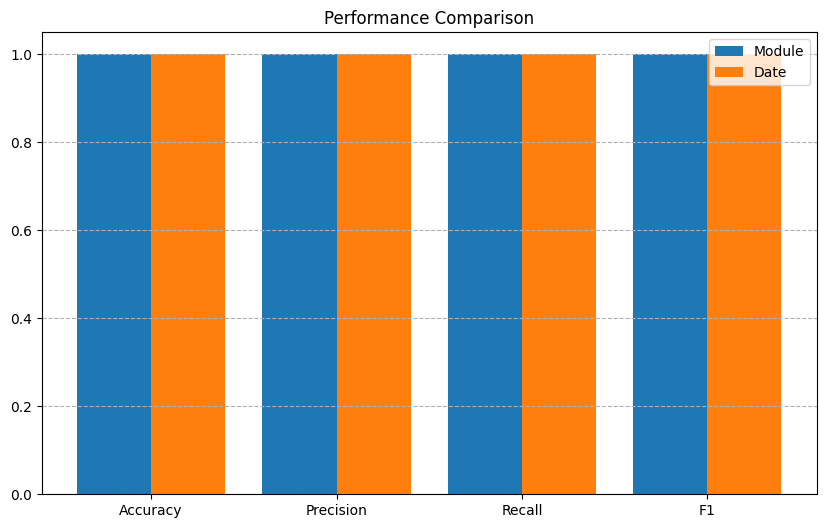

In [ ]:
metric_names = ["Accuracy", "Precision", "Recall", "F1"]
module_vals = module_metrics
date_vals   = date_metrics

plt.figure(figsize=(10,6))
x = np.arange(len(metric_names))
plt.bar(x-0.2, module_vals, 0.4, label="Module")
plt.bar(x+0.2, date_vals, 0.4, label="Date")
plt.xticks(x, metric_names)
plt.title("Performance Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--")
plt.show()

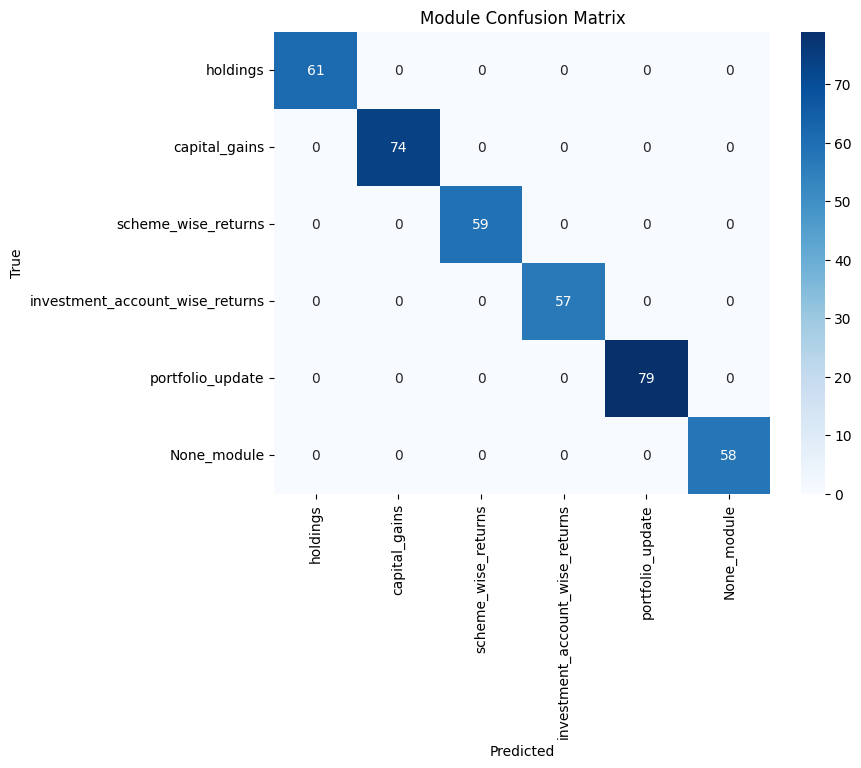

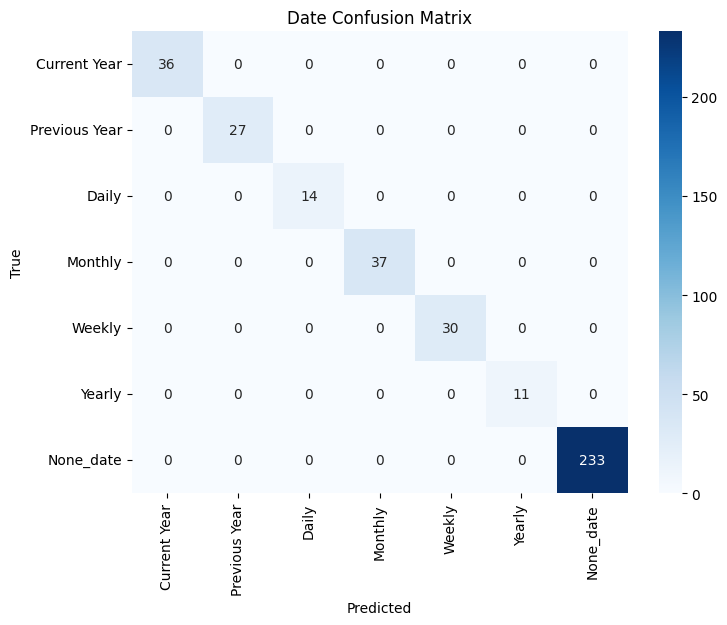

In [ ]:
def plot_cm(true, pred, classes, title):
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_cm(module_res["labels"], module_res["preds"], module_labels, "Module Confusion Matrix")
plot_cm(date_res["labels"], date_res["preds"], date_labels, "Date Confusion Matrix")

In [ ]:
import os

def print_model_size(path):
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"Model size at '{path}': {size_mb:.2f} MB")

In [ ]:
def evaluate_latency_and_metrics(
    infer_fn,
    dataset,
    warmup=True
):
    latencies = []

    module_preds, module_gt = [], []
    date_preds, date_gt = [], []

    # -------- Warm-up ONCE --------
    if warmup:
        text = dataset[0]["query"]
        enc = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
        enc.pop("token_type_ids", None)
        enc = {k: v.to(device) for k, v in enc.items()}
        for _ in range(5):
            infer_fn(enc)

    # -------- Actual evaluation --------
    for sample in dataset:
        text = sample["query"]

        enc = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
        enc.pop("token_type_ids", None)
        enc = {k: v.to(device) for k, v in enc.items()}

        t1 = time.time()
        m_logits, d_logits = infer_fn(enc)
        t2 = time.time()

        latencies.append((t2 - t1) * 1000)

        module_preds.append(m_logits.argmax(1).item())
        date_preds.append(d_logits.argmax(1).item())

        module_gt.append(sample["module_label"])
        date_gt.append(sample["date_label"])

    return {
        "latency_ms": np.mean(latencies),
        "module_preds": np.array(module_preds),
        "module_gt": np.array(module_gt),
        "date_preds": np.array(date_preds),
        "date_gt": np.array(date_gt)
    }



def fp32_infer(enc):
    with torch.no_grad():
        return model(enc["input_ids"], enc["attention_mask"])


fp32_results = evaluate_latency_and_metrics(
    fp32_infer,
    reporting["validation"],
    warmup=True
)

print(f"FP32 Mean Latency (ms): {fp32_results['latency_ms']:.2f}")


fp32_module_metrics = compute_metrics(
    "FP32 Module",
    fp32_results["module_preds"],
    fp32_results["module_gt"]
)

fp32_date_metrics = compute_metrics(
    "FP32 Date",
    fp32_results["date_preds"],
    fp32_results["date_gt"]
)

torch.save(model.state_dict(), "model_fp32.pt")
print_model_size("model_fp32.pt")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


FP32 Mean Latency (ms): 10.54

==== FP32 MODULE METRICS ====
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

==== FP32 DATE METRICS ====
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Model size at 'model_fp32.pt': 54.79 MB


In [ ]:
model_fp16 = model.half()

def fp16_infer(enc):
    with torch.no_grad():
        # input_ids must stay as Long, only attention_mask becomes half
        return model_fp16(enc["input_ids"], enc["attention_mask"].half())

fp16_results = evaluate_latency_and_metrics(fp16_infer, reporting["validation"], warmup=True)
print(f"\nFP16 Mean Latency (ms): {fp16_results['latency_ms']:.2f}")
fp16_module_metrics = compute_metrics("FP16 Module", fp16_results["module_preds"], fp16_results["module_gt"])
fp16_date_metrics = compute_metrics("FP16 Date", fp16_results["date_preds"], fp16_results["date_gt"])

torch.save(model_fp16.state_dict(), "model_fp16.pt")
print_model_size("model_fp16.pt")


FP16 Mean Latency (ms): 39.82

==== FP16 MODULE METRICS ====
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

==== FP16 DATE METRICS ====
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
Model size at 'model_fp16.pt': 27.41 MB


In [ ]:
import copy
model_for_quant = copy.deepcopy(model).cpu().float()

quant_model = torch.quantization.quantize_dynamic(
    model_for_quant, {nn.Linear}, dtype=torch.qint8
).eval()

def int8_infer(enc):
    with torch.no_grad():
        # Move to CPU and ensure correct dtypes
        input_ids = enc["input_ids"].cpu()
        attention_mask = enc["attention_mask"].cpu()

        # Convert attention_mask to float32 if it's half
        if attention_mask.dtype == torch.float16:
            attention_mask = attention_mask.float()

        return quant_model(input_ids, attention_mask)

int8_results = evaluate_latency_and_metrics(
    int8_infer, reporting["validation"], warmup=True
)
print(f"\nINT8 Mean Latency (ms): {int8_results['latency_ms']:.2f}")
int8_module_metrics = compute_metrics("INT8 Module", int8_results["module_preds"], int8_results["module_gt"])
int8_date_metrics = compute_metrics("INT8 Date", int8_results["date_preds"], int8_results["date_gt"])

torch.save(quant_model.state_dict(), "model_int8.pt")
print_model_size("model_int8.pt")

/tmp/ipython-input-3031312359.py:4: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quant_model = torch.quantization.quantize_dynamic(



INT8 Mean Latency (ms): 5.70

==== INT8 MODULE METRICS ====
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

==== INT8 DATE METRICS ====
Accuracy:  0.9716
Precision: 0.9758
Recall:    0.9716
F1 Score:  0.9710
Model size at 'model_int8.pt': 41.49 MB


In [ ]:
# quant_model = torch.quantization.quantize_dynamic(model.cpu(), {nn.Linear}, dtype=torch.qint8)
# quant_results = [measure_latency(lambda ids,mask: quant_model(ids.cpu(),mask.cpu()), q) for q in queries]

/tmp/ipython-input-316967523.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quant_model = torch.quantization.quantize_dynamic(model.cpu(), {nn.Linear}, dtype=torch.qint8)


In [ ]:
dummy_ids = torch.randint(1, 100, (1, 2))
dummy_mask = torch.ones_like(dummy_ids)

torch.onnx.export(
    model.cpu().eval(),
    (dummy_ids, dummy_mask),
    "tinybert.onnx",
    input_names=["input_ids", "attention_mask"],
    output_names=["module", "date"],
    dynamic_axes={
        "input_ids": {0: "batch", 1: "seq"},
        "attention_mask": {0: "batch", 1: "seq"}
    },
    opset_version=17
)

print("ONNX model exported successfully!")
print_model_size("tinybert.onnx")

/tmp/ipython-input-2399068398.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W1217 14:26:13.908000 147 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TinyBERTDualClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TinyBERTDualClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Applied 31 of general pattern rewrite rules.
ONNX model exported successfully!
Model size at 'tinybert.onnx': 0.04 MB


In [ ]:
session = ort.InferenceSession("tinybert.onnx")

def onnx_infer(enc):
    input_ids = enc["input_ids"].cpu().numpy().astype(np.int64)
    attention_mask = enc["attention_mask"].cpu().numpy().astype(np.int64)

    outputs = session.run(None, {
        "input_ids": input_ids,
        "attention_mask": attention_mask
    })

    # Convert back to torch tensors for consistency with evaluate_latency_and_metrics
    module_logits = torch.from_numpy(outputs[0])
    date_logits = torch.from_numpy(outputs[1])

    return module_logits, date_logits

onnx_results = evaluate_latency_and_metrics(
    onnx_infer, reporting["test"], warmup=True
)
print(f"\nONNX Mean Latency (ms): {onnx_results['latency_ms']:.2f}")

onnx_module_metrics = compute_metrics("ONNX Module", onnx_results["module_preds"], onnx_results["module_gt"])
onnx_date_metrics = compute_metrics("ONNX Date", onnx_results["date_preds"], onnx_results["date_gt"])


ONNX Mean Latency (ms): 2.77

==== ONNX MODULE METRICS ====
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

==== ONNX DATE METRICS ====
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


In [ ]:
query = "Show my holdings for this month"

enc = tokenizer(
    query,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128
)

module_logits, date_logits = onnx_infer(enc)

module_pred = module_labels[module_logits.argmax().item()]
date_pred = date_labels[date_logits.argmax().item()]

print("\n=== ONNX Single Query Test ===")
print("Query:", query)
print("Module Prediction:", module_pred)
print("Date Prediction:", date_pred)



=== ONNX Single Query Test ===
Query: Show my holdings for this month
Module Prediction: holdings
Date Prediction: Monthly


In [ ]:
print("COLAB input_ids:", inputs["input_ids"][0].tolist())
print("COLAB attention_mask:", inputs["attention_mask"][0].tolist())

COLAB input_ids: [101, 2265, 2026, 9583, 2005, 2023, 3204, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
COLAB attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


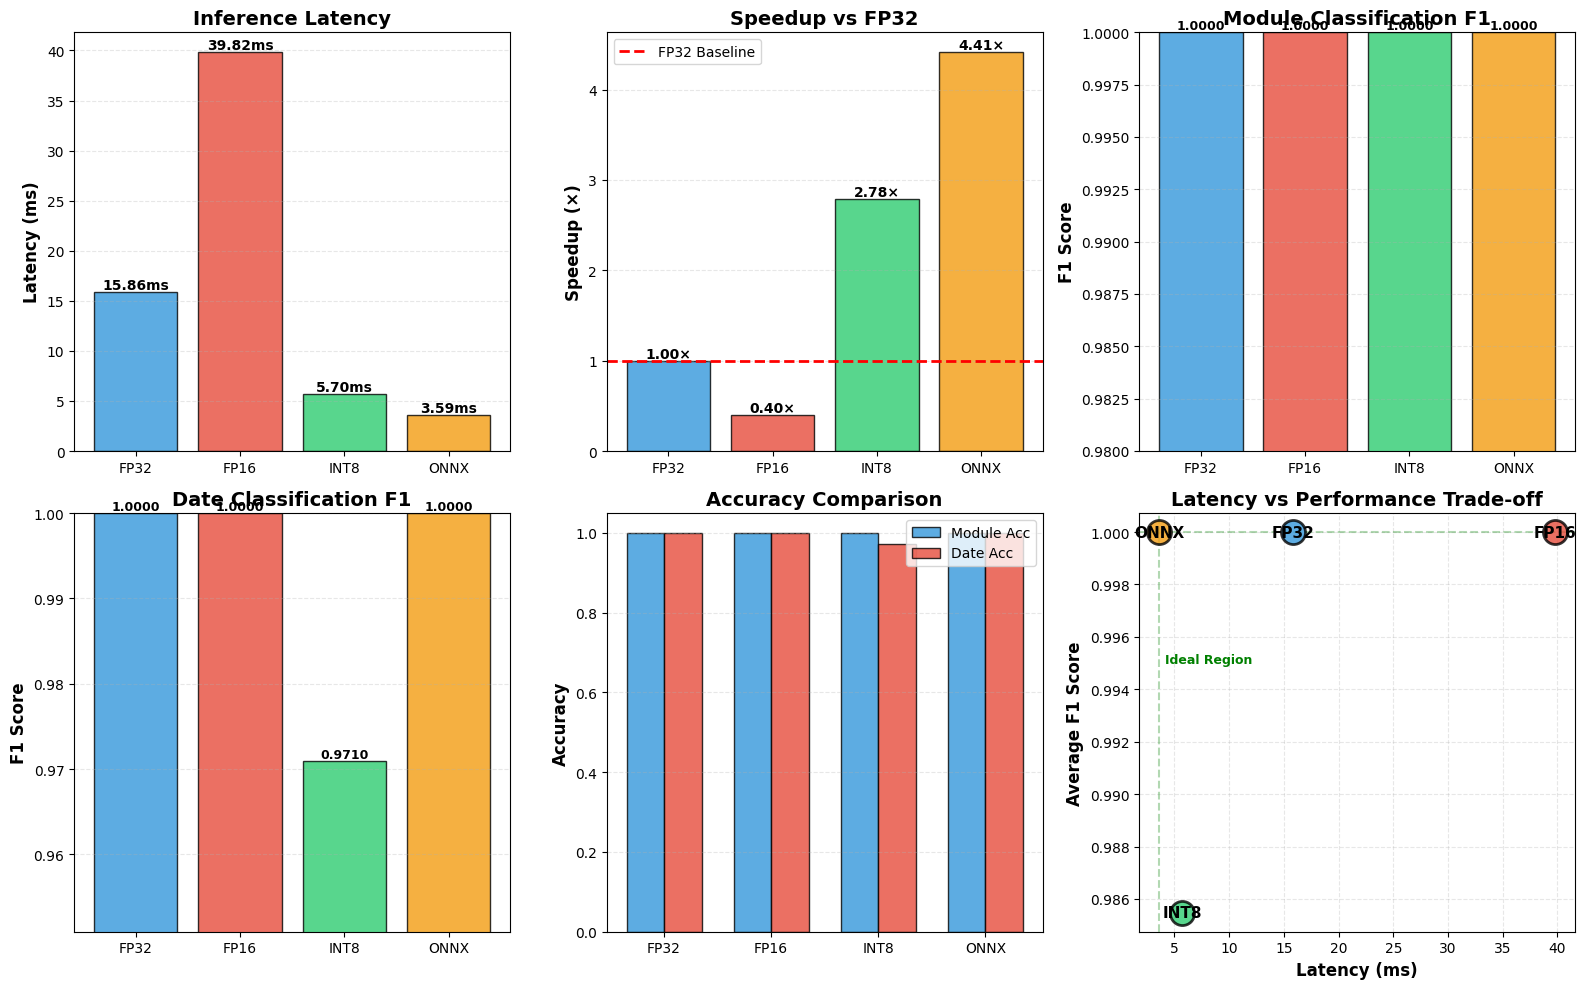


MODEL OPTIMIZATION COMPARISON SUMMARY
Model      Latency      Speedup    Module F1    Date F1      Avg F1     Module Acc   Date Acc  
--------------------------------------------------------------------------------------------------------------
FP32       15.86        1.00      × 1.0000       1.0000       1.0000     1.0000       1.0000    
FP16       39.82        0.40      × 1.0000       1.0000       1.0000     1.0000       1.0000    
INT8       5.70         2.78      × 1.0000       0.9710       0.9855     1.0000       0.9716    
ONNX       3.59         4.41      × 1.0000       1.0000       1.0000     1.0000       1.0000    

RECOMMENDATIONS

🚀 FASTEST MODEL: ONNX
   - Latency: 3.59ms
   - Speedup: 4.41× faster than FP32

🎯 MOST ACCURATE MODEL: FP32
   - Average F1: 1.0000
   - Module F1: 1.0000
   - Date F1: 1.0000
   - Latency: 15.86ms

📊 ACCURACY DEGRADATION (vs FP32):
   - FP16: 0.0000 (0.00%)
   - INT8: 0.0145 (1.45%)
   - ONNX: 0.0000 (0.00%)

💡 RECOMMENDATION:
   Use ONNX for t

In [ ]:
results_summary = {
    "FP32": {
        "latency_ms": fp32_results['latency_ms'],
        "module_acc": fp32_module_metrics[0],
        "module_prec": fp32_module_metrics[1],
        "module_rec": fp32_module_metrics[2],
        "module_f1": fp32_module_metrics[3],
        "date_acc": fp32_date_metrics[0],
        "date_prec": fp32_date_metrics[1],
        "date_rec": fp32_date_metrics[2],
        "date_f1": fp32_date_metrics[3]
    },
    "FP16": {
        "latency_ms": fp16_results['latency_ms'],
        "module_acc": fp16_module_metrics[0],
        "module_prec": fp16_module_metrics[1],
        "module_rec": fp16_module_metrics[2],
        "module_f1": fp16_module_metrics[3],
        "date_acc": fp16_date_metrics[0],
        "date_prec": fp16_date_metrics[1],
        "date_rec": fp16_date_metrics[2],
        "date_f1": fp16_date_metrics[3]
    },
    "INT8": {
        "latency_ms": int8_results['latency_ms'],
        "module_acc": int8_module_metrics[0],
        "module_prec": int8_module_metrics[1],
        "module_rec": int8_module_metrics[2],
        "module_f1": int8_module_metrics[3],
        "date_acc": int8_date_metrics[0],
        "date_prec": int8_date_metrics[1],
        "date_rec": int8_date_metrics[2],
        "date_f1": int8_date_metrics[3]
    },
    "ONNX": {
        "latency_ms": onnx_results['latency_ms'],
        "module_acc": onnx_module_metrics[0],
        "module_prec": onnx_module_metrics[1],
        "module_rec": onnx_module_metrics[2],
        "module_f1": onnx_module_metrics[3],
        "date_acc": onnx_date_metrics[0],
        "date_prec": onnx_date_metrics[1],
        "date_rec": onnx_date_metrics[2],
        "date_f1": onnx_date_metrics[3]
    }
}

# ============================================
# Create Comprehensive Visualization
# ============================================
fig = plt.figure(figsize=(16, 10))

models = list(results_summary.keys())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# 1. Latency Comparison
ax1 = plt.subplot(2, 3, 1)
latencies = [results_summary[m]['latency_ms'] for m in models]
bars1 = ax1.bar(models, latencies, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
ax1.set_title('Inference Latency', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}ms',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Speedup Comparison (relative to FP32)
ax2 = plt.subplot(2, 3, 2)
baseline_latency = results_summary['FP32']['latency_ms']
speedups = [baseline_latency / results_summary[m]['latency_ms'] for m in models]
bars2 = ax2.bar(models, speedups, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='FP32 Baseline')
ax2.set_ylabel('Speedup (×)', fontsize=12, fontweight='bold')
ax2.set_title('Speedup vs FP32', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}×',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Module Classification F1 Score
ax3 = plt.subplot(2, 3, 3)
module_f1s = [results_summary[m]['module_f1'] for m in models]
bars3 = ax3.bar(models, module_f1s, color=colors, alpha=0.8, edgecolor='black')
ax3.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax3.set_title('Module Classification F1', fontsize=14, fontweight='bold')
ax3.set_ylim([min(module_f1s) - 0.02, 1.0])
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Date Classification F1 Score
ax4 = plt.subplot(2, 3, 4)
date_f1s = [results_summary[m]['date_f1'] for m in models]
bars4 = ax4.bar(models, date_f1s, color=colors, alpha=0.8, edgecolor='black')
ax4.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax4.set_title('Date Classification F1', fontsize=14, fontweight='bold')
ax4.set_ylim([min(date_f1s) - 0.02, 1.0])
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5. Accuracy Comparison (Both Tasks)
ax5 = plt.subplot(2, 3, 5)
x = np.arange(len(models))
width = 0.35
module_accs = [results_summary[m]['module_acc'] for m in models]
date_accs = [results_summary[m]['date_acc'] for m in models]

bars5a = ax5.bar(x - width/2, module_accs, width, label='Module Acc',
                 color='#3498db', alpha=0.8, edgecolor='black')
bars5b = ax5.bar(x + width/2, date_accs, width, label='Date Acc',
                 color='#e74c3c', alpha=0.8, edgecolor='black')

ax5.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax5.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(models)
ax5.legend()
ax5.grid(axis='y', alpha=0.3, linestyle='--')

# 6. Latency vs F1 Trade-off (Scatter)
ax6 = plt.subplot(2, 3, 6)
avg_f1s = [(results_summary[m]['module_f1'] + results_summary[m]['date_f1']) / 2
           for m in models]

for i, model in enumerate(models):
    ax6.scatter(latencies[i], avg_f1s[i], s=300, c=colors[i],
                alpha=0.8, edgecolors='black', linewidth=2, zorder=3)
    ax6.annotate(model, (latencies[i], avg_f1s[i]),
                fontsize=11, fontweight='bold', ha='center', va='center')

ax6.set_xlabel('Latency (ms)', fontsize=12, fontweight='bold')
ax6.set_ylabel('Average F1 Score', fontsize=12, fontweight='bold')
ax6.set_title('Latency vs Performance Trade-off', fontsize=14, fontweight='bold')
ax6.grid(True, alpha=0.3, linestyle='--')

# Add ideal region annotation
ax6.axhline(y=max(avg_f1s), color='green', linestyle='--', alpha=0.3, linewidth=1.5)
ax6.axvline(x=min(latencies), color='green', linestyle='--', alpha=0.3, linewidth=1.5)
ax6.text(min(latencies) + 0.5, max(avg_f1s) - 0.005,
         'Ideal Region', fontsize=9, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('model_optimization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# Print Summary Table
# ============================================
print("\n" + "="*110)
print("MODEL OPTIMIZATION COMPARISON SUMMARY")
print("="*110)
print(f"{'Model':<10} {'Latency':<12} {'Speedup':<10} {'Module F1':<12} {'Date F1':<12} {'Avg F1':<10} {'Module Acc':<12} {'Date Acc':<10}")
print("-"*110)

for model in models:
    r = results_summary[model]
    speedup = baseline_latency / r['latency_ms']
    avg_f1 = (r['module_f1'] + r['date_f1']) / 2
    print(f"{model:<10} {r['latency_ms']:<12.2f} {speedup:<10.2f}× {r['module_f1']:<12.4f} {r['date_f1']:<12.4f} {avg_f1:<10.4f} {r['module_acc']:<12.4f} {r['date_acc']:<10.4f}")

print("="*110)

# ============================================
# Print Recommendations
# ============================================
print("\n" + "="*110)
print("RECOMMENDATIONS")
print("="*110)

best_latency_model = min(models, key=lambda m: results_summary[m]['latency_ms'])
best_accuracy_model = max(models, key=lambda m: (results_summary[m]['module_f1'] + results_summary[m]['date_f1']) / 2)

print(f"\n🚀 FASTEST MODEL: {best_latency_model}")
print(f"   - Latency: {results_summary[best_latency_model]['latency_ms']:.2f}ms")
print(f"   - Speedup: {baseline_latency / results_summary[best_latency_model]['latency_ms']:.2f}× faster than FP32")

print(f"\n🎯 MOST ACCURATE MODEL: {best_accuracy_model}")
avg_f1_best = (results_summary[best_accuracy_model]['module_f1'] + results_summary[best_accuracy_model]['date_f1']) / 2
print(f"   - Average F1: {avg_f1_best:.4f}")
print(f"   - Module F1: {results_summary[best_accuracy_model]['module_f1']:.4f}")
print(f"   - Date F1: {results_summary[best_accuracy_model]['date_f1']:.4f}")
print(f"   - Latency: {results_summary[best_accuracy_model]['latency_ms']:.2f}ms")

# Calculate F1 degradation for each model
print(f"\n📊 ACCURACY DEGRADATION (vs FP32):")
baseline_f1 = (results_summary['FP32']['module_f1'] + results_summary['FP32']['date_f1']) / 2
for model in models:
    if model != 'FP32':
        model_f1 = (results_summary[model]['module_f1'] + results_summary[model]['date_f1']) / 2
        degradation = baseline_f1 - model_f1
        pct_degradation = (degradation / baseline_f1) * 100
        print(f"   - {model}: {degradation:.4f} ({pct_degradation:.2f}%)")

print("\n💡 RECOMMENDATION:")
# Find best trade-off (considering both speed and accuracy)
best_tradeoff = None
best_score = -float('inf')
for model in models:
    if model != 'FP32':  # Exclude baseline
        speedup = baseline_latency / results_summary[model]['latency_ms']
        model_f1 = (results_summary[model]['module_f1'] + results_summary[model]['date_f1']) / 2
        # Score: balance between speedup and maintaining accuracy (higher is better)
        score = speedup * (model_f1 / baseline_f1)
        if score > best_score:
            best_score = score
            best_tradeoff = model

print(f"   Use {best_tradeoff} for the best balance of speed and accuracy")
print(f"   - {baseline_latency / results_summary[best_tradeoff]['latency_ms']:.2f}× faster than FP32")
model_f1 = (results_summary[best_tradeoff]['module_f1'] + results_summary[best_tradeoff]['date_f1']) / 2
acc_retention = (model_f1 / baseline_f1) * 100
print(f"   - Retains {acc_retention:.2f}% of FP32 accuracy")
print(f"   - Module F1: {results_summary[best_tradeoff]['module_f1']:.4f}")
print(f"   - Date F1: {results_summary[best_tradeoff]['date_f1']:.4f}")

print("="*110)

### Converting Model to ONNX

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig

class TinyBERTDualClassifier(nn.Module):
    def __init__(self, num_module_labels, num_date_labels, dropout_rate=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("JayShah07/tinybert-dual-classifier")
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout_rate)
        self.module_classifier = nn.Linear(hidden, num_module_labels)
        self.date_classifier = nn.Linear(hidden, num_date_labels)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.module_classifier(cls), self.date_classifier(cls)


In [ ]:
state = torch.hub.load_state_dict_from_url(
    "https://huggingface.co/JayShah07/tinybert-dual-classifier/resolve/main/classifier_heads.pt",
    map_location=torch.device('cpu')
)

model = TinyBERTDualClassifier(6,7)
model.module_classifier.load_state_dict(state["module_classifier"])
model.date_classifier.load_state_dict(state["date_classifier"])
model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


TinyBERTDualClassifier(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, e

In [ ]:
import torch.onnx

dummy = {
    "input_ids": torch.randint(0, 30522, (1,128)),
    "attention_mask": torch.ones(1,128, dtype=torch.long)
}

torch.onnx.export(
    model,
    (dummy["input_ids"], dummy["attention_mask"]),
    "tinybert_dual_classifier.onnx",
    input_names=["input_ids", "attention_mask"],
    output_names=["module_logits", "date_logits"],
    dynamic_axes={
        "input_ids": {0: "batch", 1: "seq"},
        "attention_mask": {0: "batch", 1: "seq"},
        "module_logits": {0:"batch"},
        "date_logits": {0:"batch"}
    },
    opset_version=18
)


/tmp/ipython-input-935566534.py:8: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `TinyBERTDualClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TinyBERTDualClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 31 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.9.1+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input_ids"<INT64,[s72,s53]>,
                %"attention_mask"<INT64,[s43,s53]>
            ),
            outputs=(
                %"module_logits"<FLOAT,[1,6]>,
                %"date_logits"<FLOAT,[1,7]>
            ),
            initializers=(
                %"encoder.embeddings.word_embeddings.weight"<FLOAT,[30522,312]>{TorchTensor(...)},
                %"encoder.embeddings.position_embeddings.weight"<FLOAT,[512,312]>{TorchTensor(...)},
                %"encoder.embeddings.token_type_embeddings.weight"<FLOAT,[2,312]>{TorchTensor(...)},
                %"encoder.embeddings.LayerNorm.weight"<FLOAT,[312]>{TorchTensor(...)},
                %"encoder.embeddin

In [ ]:
!pip install onnx onnxsim onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 58.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for onnxsim: filename=onnxsim-0.4.36-cp312-cp312-linux_x86_64.whl size=2200371 sha256=bb3268855642890a013bb5eb1d2340cdd7a4d95524161f1a5c91fb4ffcf1a23b
  Stored in directory: /root/.cache/pip/wheels/73/5d/cc/db1350d9fabfe7f8442b5d97aff2ff543fc253277f71a6508f
Successfully built onnxsim


In [ ]:
import onnx
from onnxsim import simplify

model = onnx.load("tinybert_dual_classifier.onnx")
model_simp, check = simplify(model)

assert check, "Simplified ONNX model could not be validated"

onnx.save(model_simp, "tinybert_dual_classifier_simplified.onnx")
print("Saved simplified model.")

Saved simplified model.


In [ ]:
import onnxruntime as ort

sess_opts = ort.SessionOptions()
sess_opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

session = ort.InferenceSession(
    "tinybert_dual_classifier_simplified.onnx",
    sess_opts,
    providers=["CPUExecutionProvider"]
)

In [ ]:
def infer(text):
    encoded = tokenizer.encode(text)
    ids = encoded.ids
    if len(ids) < 128:
        ids += [0] * (128 - len(ids))
    ids = ids[:128]

    input_ids = np.array([ids], dtype=np.int64)
    attn = np.array([[1]*128], dtype=np.int64)

    outputs = sess.run(
        None,
        {"input_ids": input_ids, "attention_mask": attn}
    )

    module_logits, date_logits = outputs
    return module_logits.argmax(), date_logits.argmax()


In [ ]:
module_idx, date_idx = infer("Show my holdings for this month")

module_labels = ['holdings', 'capital_gains', 'scheme_wise_returns',
                 'investment_account_wise_returns', 'portfolio_update', 'None_module']

date_labels = ['Current Year', 'Previous Year', 'Daily', 'Monthly',
               'Weekly', 'Yearly', 'None_date']

print("Module:", module_labels[module_idx])
print("Date:", date_labels[date_idx])

NameError: name 'tokenizer' is not defined